# EDA for `train_dim12.json`

This notebook is for **understanding the dataset itself** before doing clustering.

Goals:
- understand what one utterance entry contains
- connect the JSON fields to speech/audio concepts
- inspect the shapes, labels, and timing conventions
- build intuition for what the model input and supervision actually are
- identify what representation makes sense for clustering later


## Audio Domain Primer

For speech data, the original signal is a waveform: amplitude over time.

A typical feature pipeline is:
1. waveform
2. split into short overlapping frames
3. compute spectral features per frame
4. store one feature vector per frame

Here, each utterance contains a sequence of **12-dimensional frame-level features**.
These are very likely 12 static MFCC-like coefficients per frame.

How to read a shape like `(349, 12)`:
- `349` = number of time frames in the utterance
- `12` = number of features for each frame

So the data for one utterance is not a single vector. It is a **time sequence** of frame vectors.

Rough intuition:
- each frame covers a very short slice of audio
- neighboring frames are correlated
- several consecutive frames often belong to the same phoneme
- phoneme boundaries are approximate time/frame spans over this sequence


In [1]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")

with open("train_dim12.json", "r") as f:
    data = json.load(f)

print(type(data))
print("num utterances:", len(data))


<class 'dict'>
num utterances: 4620


## What Is One JSON Entry?

Each top-level key is one **utterance**.

From the data you inspected earlier, each utterance has:
- `features`: frame-level feature matrix
- `feat_shape`: stored shape metadata
- `phn_transcript`: phoneme transcript with boundary information
- `phn_wise_segment`: phoneme labels only, segment by segment
- `segment_boundary`: boundary positions in frame indices
- `no_segments`: count related to segmentation metadata

The important point is that the **input** is the feature sequence, while the phoneme-related fields are the **annotation / supervision / evaluation metadata**.


In [2]:
first_key = next(iter(data))
first_entry = data[first_key]
first_feat = np.asarray(first_entry["features"], dtype=np.float32)

print("first utterance id:", first_key)
print("fields:", list(first_entry.keys()))
print("feature matrix shape:", first_feat.shape)
print("stored feat_shape:", first_entry["feat_shape"])
print("no_segments:", first_entry["no_segments"])
print("num phoneme labels:", len(first_entry["phn_wise_segment"]))
print("num transcript rows:", len(first_entry["phn_transcript"]))
print("num boundaries:", len(first_entry["segment_boundary"]))
print()
print("first 3 feature vectors:")
print(np.round(first_feat[:3], 3))
print()
print("first 5 transcript entries:")
print(first_entry["phn_transcript"][:5])
print()
print("first 10 boundaries:")
print(first_entry["segment_boundary"][:10])


first utterance id: FEXM0_SX291
fields: ['features', 'feat_shape', 'phn_transcript', 'phn_wise_segment', 'segment_boundary', 'no_segments']
feature matrix shape: (349, 12)
stored feat_shape: [349, 12]
no_segments: 37
num phoneme labels: 36
num transcript rows: 36
num boundaries: 37

first 3 feature vectors:
[[-6.73028e+02  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
   0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
   0.00000e+00  0.00000e+00]
 [-6.73028e+02  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
   0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
   0.00000e+00  0.00000e+00]
 [-6.72548e+02  6.66000e-01  6.30000e-01  5.72000e-01  4.93000e-01
   3.97000e-01  2.87000e-01  1.67000e-01  4.10000e-02 -8.70000e-02
  -2.11000e-01 -3.27000e-01]]

first 5 transcript entries:
[['sil', 0, 13], ['dh', 13, 16], ['iy', 16, 30], ['sil', 30, 37], ['ae', 37, 56]]

first 10 boundaries:
[0, 13, 16, 30, 37, 56, 62, 72, 81, 103]


In [4]:
print("last 5 transcript entries:")
print(first_entry["phn_transcript"][-5:])

last 5 transcript entries:
[['w', 300, 305], ['ey', 305, 314], ['sil', 314, 327], ['k', 327, 331], ['sil', 331, 348]]


## How to Interpret the Fields

`features`
- shape `(T, 12)`
- this is the actual acoustic input sequence for the utterance
- row `t` is the 12D feature vector for frame `t`

`phn_transcript`
- a list like `['aa', start, end]`
- each row says: frames from `start` to `end` correspond to that phoneme label
- in practice, this is the cleanest field for building segment-level examples

`phn_wise_segment`
- the phoneme labels without explicitly repeating boundaries in each row
- useful for fast label counting and consistency checks

`segment_boundary`
- the sequence of frame boundary points between segments
- usually aligns with the start/end fields in `phn_transcript`

`no_segments`
- related to the boundary representation
- you will notice it is typically one more than the number of labeled phoneme segments, because boundaries count cut points, not just labeled spans

For clustering:
- **input candidates** = frame vectors, pooled segment vectors, or utterance-level pooled vectors
- **output/ground truth for evaluation** = phoneme labels from `phn_transcript` / `phn_wise_segment`


In [5]:
def summarize_utterance(utt_id):
    entry = data[utt_id]
    feats = np.asarray(entry["features"], dtype=np.float32)
    transcript = entry["phn_transcript"]
    labels = entry["phn_wise_segment"]
    boundaries = entry["segment_boundary"]

    print("utterance:", utt_id)
    print("feature shape:", feats.shape)
    print("feat_shape field:", entry["feat_shape"])
    print("num transcript rows:", len(transcript))
    print("num labels:", len(labels))
    print("num boundaries:", len(boundaries))
    print("no_segments:", entry["no_segments"])
    print("first 8 labels:", labels[:8])
    print("first 8 boundaries:", boundaries[:8])
    print("last 5 transcript rows:")
    print(transcript[-5:])

summarize_utterance(first_key)


utterance: FEXM0_SX291
feature shape: (349, 12)
feat_shape field: [349, 12]
num transcript rows: 36
num labels: 36
num boundaries: 37
no_segments: 37
first 8 labels: ['sil', 'dh', 'iy', 'sil', 'ae', 'v', 'l', 'l']
first 8 boundaries: [0, 13, 16, 30, 37, 56, 62, 72]
last 5 transcript rows:
[['w', 300, 305], ['ey', 305, 314], ['sil', 314, 327], ['k', 327, 331], ['sil', 331, 348]]


## Global Structure EDA

These summaries answer basic questions such as:
- how long utterances are
- how many total frames there are
- how many phoneme segments there are
- whether the annotation is structurally consistent


In [6]:
utterance_ids = list(data.keys())
frame_lengths = np.array([len(v["features"]) for v in data.values()])
num_label_segments = np.array([len(v["phn_wise_segment"]) for v in data.values()])
num_transcript_segments = np.array([len(v["phn_transcript"]) for v in data.values()])
num_boundaries = np.array([len(v["segment_boundary"]) for v in data.values()])

summary_df = pd.DataFrame([
    {"quantity": "num_utterances", "value": len(data)},
    {"quantity": "total_frames", "value": int(frame_lengths.sum())},
    {"quantity": "min_frames_per_utt", "value": int(frame_lengths.min())},
    {"quantity": "median_frames_per_utt", "value": float(np.median(frame_lengths))},
    {"quantity": "mean_frames_per_utt", "value": round(float(frame_lengths.mean()), 2)},
    {"quantity": "max_frames_per_utt", "value": int(frame_lengths.max())},
    {"quantity": "total_labeled_segments", "value": int(num_label_segments.sum())},
    {"quantity": "mean_labeled_segments_per_utt", "value": round(float(num_label_segments.mean()), 2)},
])

display(summary_df)


,quantity,value
0,num_utterances,4620.00
1,total_frames,1421707.00
2,min_frames_per_utt,92.00
3,median_frames_per_utt,296.00
4,mean_frames_per_utt,307.73
5,max_frames_per_utt,779.00
6,total_labeled_segments,177080.00
7,mean_labeled_segments_per_utt,38.33


In [7]:
consistency_rows = []

for utt_id, entry in data.items():
    T = len(entry["features"])
    transcript = entry["phn_transcript"]
    labels = entry["phn_wise_segment"]
    boundaries = entry["segment_boundary"]

    transcript_label_match = [row[0] for row in transcript] == labels
    transcript_boundary_match = all(
        transcript[i][1] == boundaries[i] and transcript[i][2] == boundaries[i + 1]
        for i in range(len(transcript))
    )

    consistency_rows.append({
        "utt_id": utt_id,
        "T": T,
        "label_count": len(labels),
        "transcript_count": len(transcript),
        "boundary_count": len(boundaries),
        "no_segments": entry["no_segments"],
        "labels_match_transcript": transcript_label_match,
        "transcript_matches_boundaries": transcript_boundary_match,
        "last_transcript_end": transcript[-1][2] if transcript else None,
    })

consistency_df = pd.DataFrame(consistency_rows)

print("labels match transcript for all utterances:", consistency_df["labels_match_transcript"].all())
print("transcript matches boundaries for all utterances:", consistency_df["transcript_matches_boundaries"].all())
print()
print("last transcript end value counts:")
print(consistency_df["last_transcript_end"].sub(consistency_df["T"]).value_counts().sort_index().head(10))


labels match transcript for all utterances: True
transcript matches boundaries for all utterances: False

last transcript end value counts:
-40    2
-37    1
-25    3
-24    2
-19    2
-18    1
-17    1
-16    1
-15    2
-14    3
Name: count, dtype: int64


## Distribution of Utterance Lengths

This tells you whether the dataset has mostly short clips, long clips, or a wide spread.


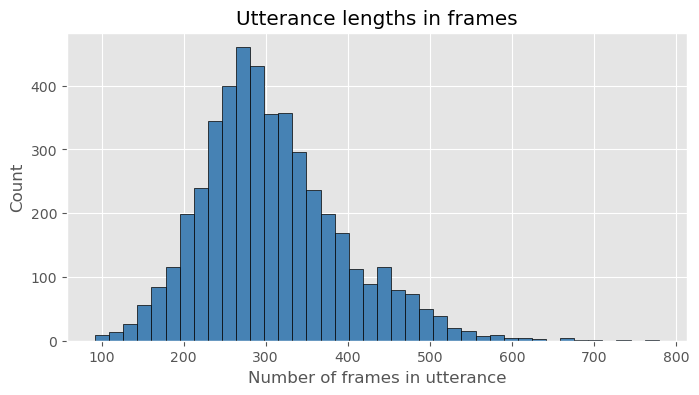

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(frame_lengths, bins=40, color="steelblue", edgecolor="black")
ax.set_title("Utterance lengths in frames")
ax.set_xlabel("Number of frames in utterance")
ax.set_ylabel("Count")
plt.show()


## Phoneme Label Inventory

This is the label space that later clustering will be compared against.


num unique phoneme labels: 39


,phoneme,count
0,sil,39467
1,ih,13693
2,n,8762
3,s,7475
4,iy,6953
5,l,6752
6,r,6539
7,ah,6291
8,aa,6004
9,er,5453


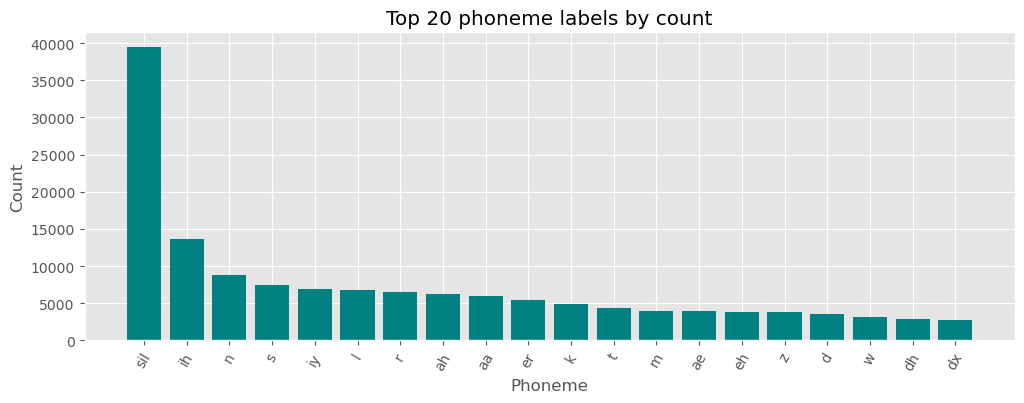

In [9]:
phoneme_counter = Counter()
for entry in data.values():
    phoneme_counter.update(entry["phn_wise_segment"])

phoneme_df = pd.DataFrame(phoneme_counter.items(), columns=["phoneme", "count"])
phoneme_df = phoneme_df.sort_values("count", ascending=False).reset_index(drop=True)

print("num unique phoneme labels:", len(phoneme_df))
display(phoneme_df.head(20))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(phoneme_df["phoneme"].head(20), phoneme_df["count"].head(20), color="teal")
ax.set_title("Top 20 phoneme labels by count")
ax.set_xlabel("Phoneme")
ax.set_ylabel("Count")
plt.xticks(rotation=60)
plt.show()


## Segment Durations

A segment duration here is the number of frames assigned to one phoneme label.

This matters because:
- very short segments are unstable
- silence segments are often longer
- pooled segment features behave differently for very short vs long segments


usable segments: 176997


count    176997.000000
mean          8.020916
std           6.406746
min           1.000000
25%           4.000000
50%           7.000000
75%          10.000000
max         299.000000
Name: duration_frames, dtype: float64

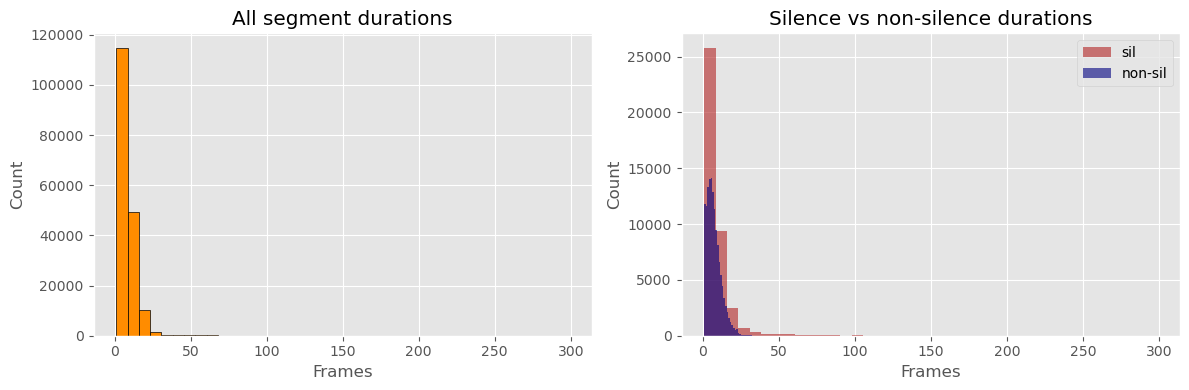

In [10]:
segment_rows = []
for utt_id, entry in data.items():
    T = len(entry["features"])
    transcript = entry["phn_transcript"]
    for seg_idx, (label, start, end) in enumerate(transcript):
        start = int(start)
        end = int(end)
        if seg_idx == len(transcript) - 1 and end == T - 1:
            end = T
        start = max(start, 0)
        end = min(end, T)
        if end <= start:
            continue
        segment_rows.append({
            "utt_id": utt_id,
            "label": label,
            "duration_frames": end - start,
        })

segment_df = pd.DataFrame(segment_rows)
print("usable segments:", len(segment_df))
display(segment_df["duration_frames"].describe())

dur_by_type = segment_df.assign(group=np.where(segment_df["label"] == "sil", "sil", "non-sil"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(segment_df["duration_frames"], bins=40, color="darkorange", edgecolor="black")
axes[0].set_title("All segment durations")
axes[0].set_xlabel("Frames")
axes[0].set_ylabel("Count")

for group, color in [("sil", "firebrick"), ("non-sil", "navy")]:
    vals = dur_by_type.loc[dur_by_type["group"] == group, "duration_frames"]
    axes[1].hist(vals, bins=40, alpha=0.6, label=group, color=color)
axes[1].set_title("Silence vs non-silence durations")
axes[1].set_xlabel("Frames")
axes[1].set_ylabel("Count")
axes[1].legend()
plt.tight_layout()
plt.show()


## Feature Value EDA

This answers questions like:
- are some coefficients much larger than others?
- do we need scaling before distance-based clustering?

If one coefficient has much larger magnitude, DBSCAN distance will be dominated by that dimension unless we standardize the data.


,dim,mean,std,min,max
0,0,-506.673401,127.787376,-881.572937,-167.932327
1,1,69.122223,64.290764,-163.237381,240.244202
2,2,-21.119114,38.381760,-191.853516,121.393890
3,3,4.356936,31.706741,-123.331383,137.822037
4,4,-20.802006,26.075657,-151.015381,88.853813
5,5,-13.152521,20.179323,-100.285065,70.325912
6,6,-14.172121,17.965359,-117.216393,59.458729
7,7,-12.519314,17.886225,-102.695534,52.814186
8,8,-5.008406,14.086479,-80.125351,63.237728
9,9,-9.149140,14.619852,-87.007217,60.333328


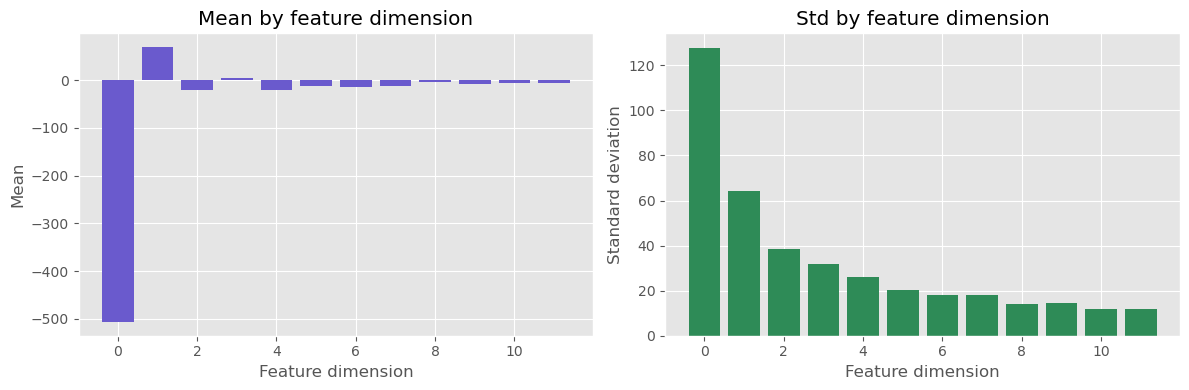

In [11]:
all_frames = np.concatenate([
    np.asarray(entry["features"], dtype=np.float32)
    for entry in data.values()
], axis=0)

feature_stats = pd.DataFrame({
    "dim": np.arange(all_frames.shape[1]),
    "mean": all_frames.mean(axis=0),
    "std": all_frames.std(axis=0),
    "min": all_frames.min(axis=0),
    "max": all_frames.max(axis=0),
})

display(feature_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(feature_stats["dim"], feature_stats["mean"], color="slateblue")
axes[0].set_title("Mean by feature dimension")
axes[0].set_xlabel("Feature dimension")
axes[0].set_ylabel("Mean")

axes[1].bar(feature_stats["dim"], feature_stats["std"], color="seagreen")
axes[1].set_title("Std by feature dimension")
axes[1].set_xlabel("Feature dimension")
axes[1].set_ylabel("Standard deviation")
plt.tight_layout()
plt.show()


## Visualizing One Utterance

This plot helps connect the abstract JSON fields to speech structure:
- the heatmap shows the 12 feature dimensions over time
- the vertical lines show phoneme boundaries
- the labels show which phoneme spans which region

This is one of the most useful cells for building intuition.


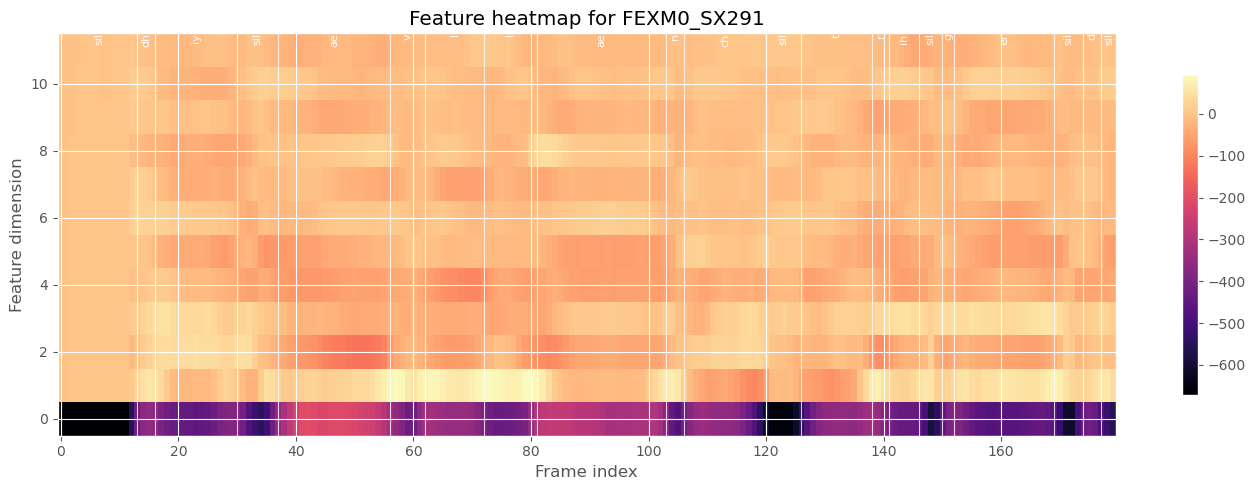

In [12]:
example_utt = first_key
entry = data[example_utt]
feats = np.asarray(entry["features"], dtype=np.float32)
transcript = entry["phn_transcript"]

max_frames_to_plot = min(180, feats.shape[0])
plot_feats = feats[:max_frames_to_plot].T

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(plot_feats, aspect="auto", origin="lower", cmap="magma")
ax.set_title(f"Feature heatmap for {example_utt}")
ax.set_xlabel("Frame index")
ax.set_ylabel("Feature dimension")
plt.colorbar(im, ax=ax, shrink=0.8)

for label, start, end in transcript:
    if start >= max_frames_to_plot:
        break
    ax.axvline(start, color="white", linewidth=0.8, alpha=0.8)
    mid = min((start + min(end, max_frames_to_plot)) / 2, max_frames_to_plot - 1)
    ax.text(mid, feats.shape[1] - 0.5, label, color="white", fontsize=8, ha="center", va="top", rotation=90)

plt.tight_layout()
plt.show()


## What Is the Input and What Is the Output?

If you think like a machine learning pipeline:

Possible **inputs**:
- frame-level sequence: `features` with shape `(T, 12)`
- segment-level pooled vectors: derived by slicing `features[start:end]` using `phn_transcript`
- utterance-level pooled vector: one vector for the whole utterance

Possible **targets / supervision / evaluation labels**:
- phoneme label per segment from `phn_transcript`
- phoneme sequence from `phn_wise_segment`
- segment boundaries from `segment_boundary`

For your current clustering problem:
- the raw stored input is **frame-level acoustic data**
- the most useful evaluation output is **phoneme identity at the segment level**
- this is why segment-level pooled features are usually the most meaningful compromise


## Domain Takeaways

What this dataset is telling you:
- each utterance is a variable-length sequence of short-time acoustic frames
- phonemes are not stored as separate vectors; they are stored as **time spans over the frame sequence**
- several adjacent frames belong to the same phoneme
- silence is common and can dominate clustering
- feature scales differ by dimension, so scaling matters for distance-based methods
- if you want phoneme-like clustering, the natural unit is usually a **segment representation**, not raw frames and not full utterances

Reasonable next notebook after this one:
- build clean segment examples from `phn_transcript`
- compare `mean12` vs `[mean12, std12, log_duration]`
- then retry clustering with objective evaluation
